# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set global font sizes

In [2]:
import matplotlib as mpl
# Set global font sizes
mpl.rcParams.update({
    'font.size': 12,              # Base font size
    'axes.titlesize': 14,         # Title size of each subplot
    'axes.labelsize': 12,         # x and y axis label size
    'xtick.labelsize': 12,        # X tick label size
    'ytick.labelsize': 12,        # Y tick label size
    'legend.fontsize': 12,        # Legend text size
    'figure.titlesize': 12,       # Main figure title
    'legend.fontsize': 12         # Legend text size
})


# - Replenishment Order Strategy 1:
### Supply Chain:
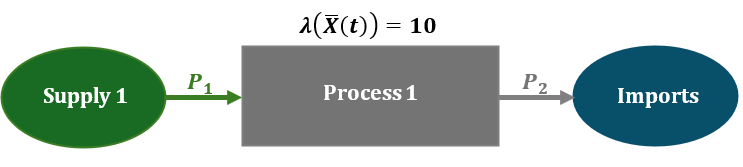
### $P_1 \xrightarrow{\lambda(\overline{X}(t))=10} P_2$ 
### Inventory Management using safeguard constant strategy for $X_1(0) = 100$

In [35]:
#######################################################################################################################
# The stochastic push system function
# The starting point for the Stochastic Push System
def inventory_basic_sc1(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, X_s, S_p, inventories):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = inventories
        queue_delay = []
        queue_count = 0
        t = 0

#######################################################################################################################
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
        
        while t < T:
            X[:, count + 1] = X[:, count]

#================ Safety stock setup X_p(t) = X[:, count], Safeguard= S_p, Safety stock = X_s =====================#
            for p in range(len(X_s)):                     # or len(S_p)
                if X[p, count + 1] <= X_s[p]:
                    X[p, count + 1] += S_p[p]
            
            Delta_C_j = np.random.poisson(lambda_j * tau)

            # Cap consumption based on available inventory
            for j in range(J):
                for i in range(nd):
                    if C_j_c[i, j] < 0:
                        max_possible = int(X[i, count + 1] / abs(C_j_c[i, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])
                queue_count += 1

# Instantaneous consumption algorithm ends here
#######################################################################################################################

#######################################################################################################################
# Compute the delayed production
# The delayed production algorithm Starts here

            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

            if (t + tau) >= T:
                tau = T - t
            t += tau
            count += 1
# The delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    # Average over all runs
    X_avg = np.mean(X_all, axis=0)                # axis = 0 helps to average the state vectors  down the columns (vertically)  
    return X_avg, time

#######################################################################################################################
#######################################################################################################################

# Simulation of result
# Inputs
nd = 2                                     # total number of dimensions
J = 1                                      # total number of processes
N = 500                                   # number of Monte Carlo paths
T = 100                                    # Total simulation time

inventories = np.array([10, 0])

# safety stock
X_s = [60]       #(4/2 + 1)*(lambda=10* tau=2)                

# Safeguard
S_p = [60]                     


# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[10, 10]])                 # Process 1: P_1 --> P_2

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[-1],[ 0]])

#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[0],[ 1]])

#======================= lambda_j values =======================#
lambda_j = np.array([10])

#======================= Plot colors =======================#
colors = ['Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$"]

# Plot

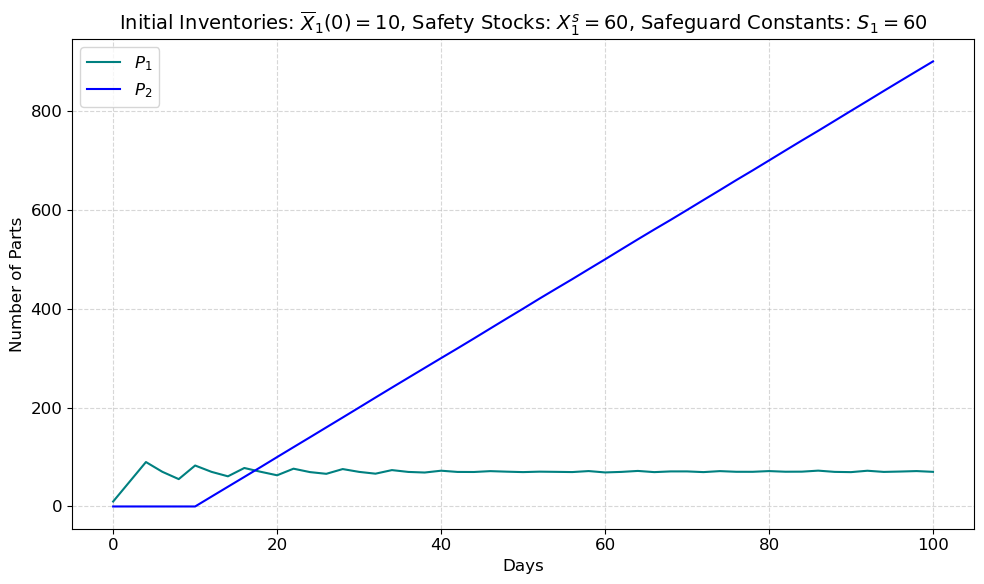

In [36]:
# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc1(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, X_s, S_p, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_1(0) = {inventories[0]}$, Safety Stocks: $X_1^s = {X_s[0]}$, Safeguard Constants: $S_1 = {S_p[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig("basic_sc_replenishment.png", format="png", bbox_inches="tight")
    plt.show()

# - Replenishment Order Strategy 2:
### Supply Chain: 
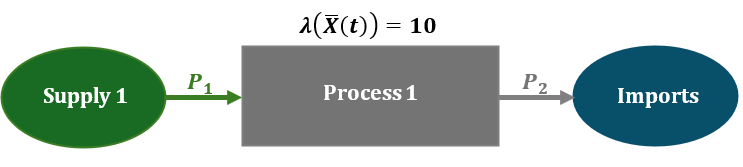
### $P_1 \xrightarrow{\lambda(\overline{X}(t))=10} P_2$ 
### Inventory Management using Safety stock and safeguard constant Strategy for $\overline{X}_1(0) = 100$

In [3]:
#######################################################################################################################
# The stochastic push system function
# The starting point for the Stochastic Push System
def inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = inventories
        queue_delay = []
        queue_count = 0
        t = 0

#######################################################################################################################
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
        
        while t < T:
            X[:, count + 1] = X[:, count]

#================ Safety stock setup X_p(t) = X[:, count], Safeguard= S_p, Safety stock = X_s =====================#
            for p in range(len(X_s)):
                if X[p, count + 1] <= X_s[p]:
                    X[p, count + 1] += S_p[p] + X_s[p] - X[p, count + 1]
            
            Delta_C_j = np.random.poisson(lambda_j * tau)

            # Cap consumption based on available inventory
            for j in range(J):
                for i in range(nd):
                    if C_j_c[i, j] < 0:
                        max_possible = int(X[i, count + 1] / abs(C_j_c[i, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])
                queue_count += 1

# Instantaneous consumption algorithm ends here
#######################################################################################################################

#######################################################################################################################
# Compute the delayed production
# The delayed production algorithm Starts here
            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

            if (t + tau) >= T:
                tau = T - t
            t += tau
            count += 1
# The delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    # Average over all runs
    X_avg = np.mean(X_all, axis=0)                # axis = 0 helps to average the state vectors  down the columns (vertically)  
    return X_avg, time

#######################################################################################################################
#######################################################################################################################

# Print out

In [12]:
## Simulation of result
# Inputs
nd = 2                                     # total number of dimensions
J = 1                                      # total number of processes
N = 500                                   # number of Monte Carlo paths
# T = 1000                                    # Total simulation time
T = 100                                    # Total simulation time

# Initial inventories
inventories = np.array([10, 0])
                                   
# safety stock
X_s = [60]       #(4/2 + 1)*(lambda=10* tau=2)                

# Safeguard
S_p = [60]                     


# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[5, 5]])                 # Process 1: P_1 --> P_2

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[-1],                  # P_1 was consumed in Proc 1
                  [0]])                  # P_2 not consumed in Proc 1

#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[0],                  # P_1 not produced in Proc 1
                  [1]])                 # P_2 was produced in Proc 1

#======================= lambda_j values =======================#
lambda_j = np.array([10])

#======================= Plot colors =======================#
colors = ['Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$"]

# Plot

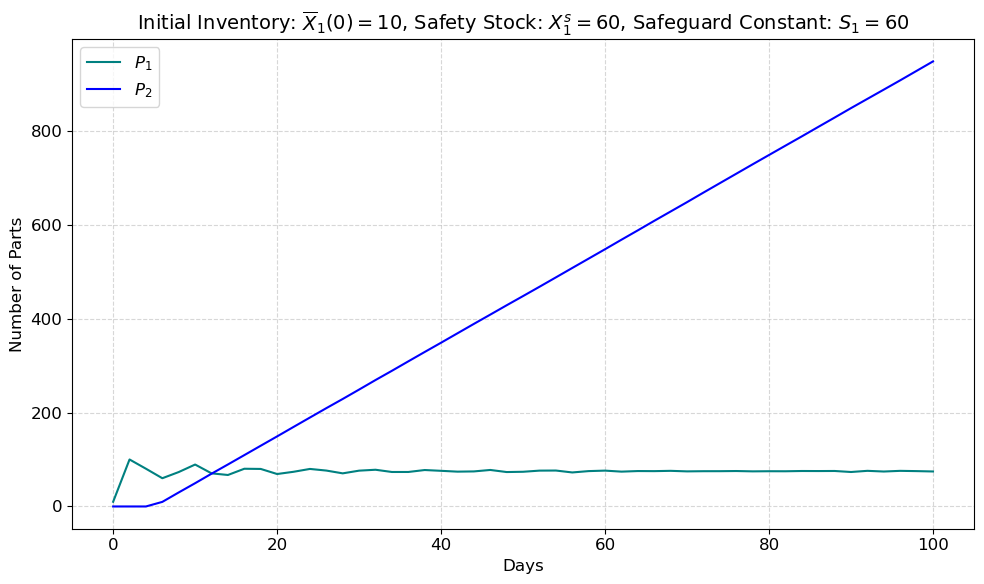

In [36]:
# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = {inventories[0]}$, Safety Stock: $X_1^s = {X_s[0]}$, Safeguard Constant: $S_1 = {S_p[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_1.png", format="png", bbox_inches="tight")
    plt.show()

# - Replenishment Order Strategy 2:
### Supply Chain: 
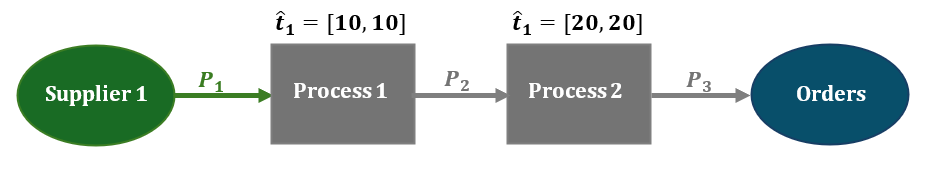
### $P_1 \xrightarrow{\lambda_1(\overline{X}(t))=10} P_2$ and $P_2 \xrightarrow{\lambda_2(\overline{X}(t))=5} P_3$ 
### Inventory Management using Safety stock and safeguard constant Strategy for $\overline{X}_1(0) = 100$

In [49]:
# Problem setup
#=========================================================###=========================================================#
nd = 3                                        # total number of dimensions (number of parts)
J = 2                                         # total number of processes
N = 100                                       # number of Monte Carlo paths
T = 1000                                       # Total simulation time

# Initial inventories
inventories = np.array([100, 0, 0])


#================================ Process time ranges t_min = pT[i,0], t_max = pT[i,1] ================================#
pT = np.array([[10, 10], [20, 20]])                    # shape (J,2)       with no delay start = end


#================================ Consumption vector ================================#
C_j_c = np.array([[-1, 0],                  # P1 consumed by process 1
                  [0, -1],                  # P2 consumed by process 2
                  [0, 0]])                  # P3 not consumed               # (3,2)

#================================ Production vector ================================#
C_j_p = np.array([[0, 0],                   # P1 not produced
                  [1, 0],                   # P2 produced by process 1
                  [0, 1]])                  # P3 produced by process 2     # (3,2)

#======================= Plot colors =======================#
colors = ['Teal', 'Red', 'Blue']
labels = [r"$P_1$", r"$P_2$", r'$P_3$']

#=========================================================###=========================================================#

# Plot for $\lambda_1 > \lambda_2$

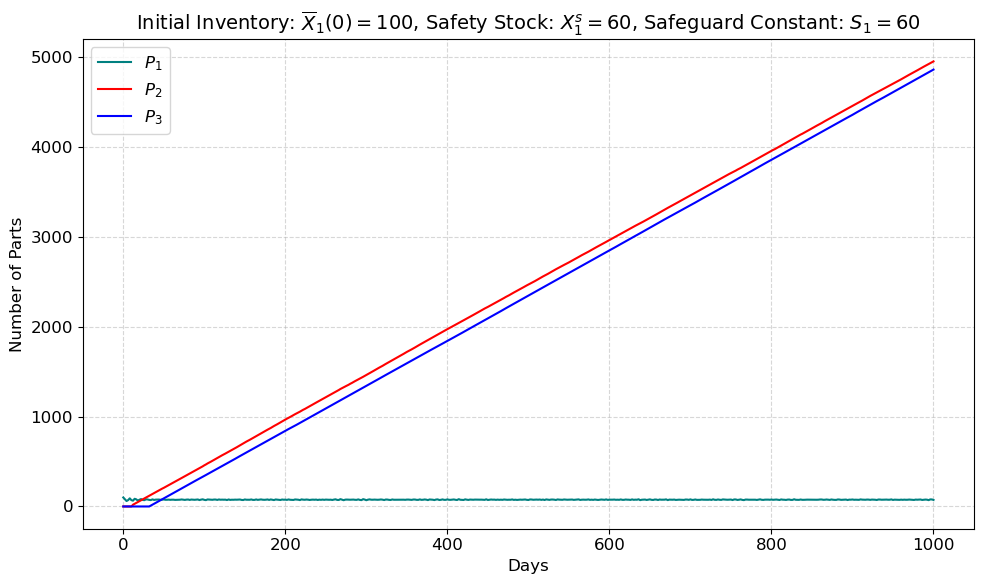

In [50]:
# safety stock
X_s = [60]       #(4/2 + 1)*(lambda=10* tau=2)                

# Safeguard
S_p = [60]    

#================================ lambda_j values ================================#
lambda_j = np.array([10, 5])

# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = 100$, Safety Stock: $X_1^s = {X_s[0]}$, Safeguard Constant: $S_1 = {S_p[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_2a.png", format="png", bbox_inches="tight")
    plt.show()

# Plot for $\lambda_1 \leq \lambda_2$

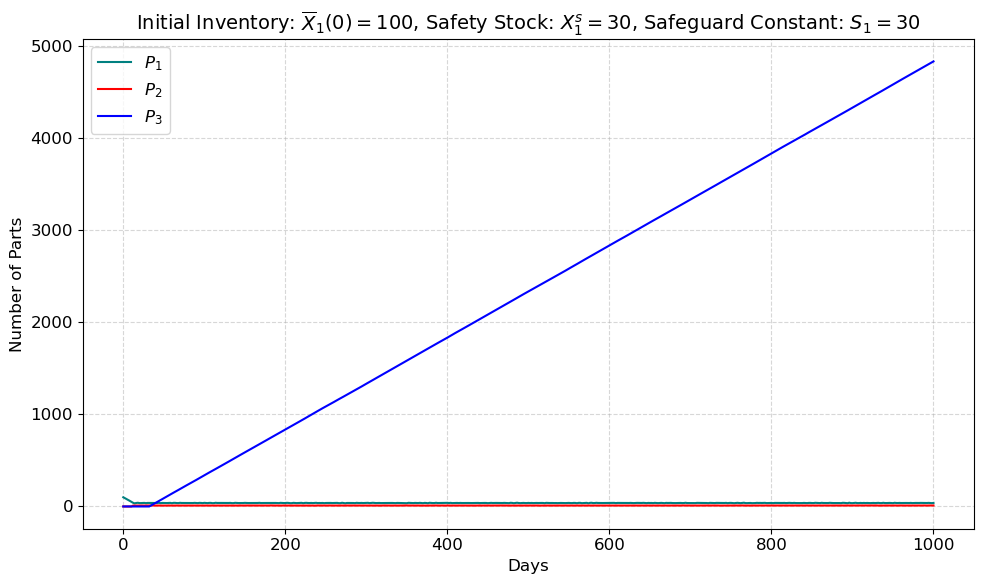

In [51]:
# safety stock
X_s = [30]       #(4/2 + 1)*(lambda=5* tau=2)                

# Safeguard
S_p = [30]    

#================================ lambda_j values ================================#
lambda_j = np.array([5, 10])

# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = 100$, Safety Stock: $X_1^s = {X_s[0]}$, Safeguard Constant: $S_1 = {S_p[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_2b.png", format="png", bbox_inches="tight")
    plt.show()

# - Replenishment Order Strategy 2
### Supply Chain: 
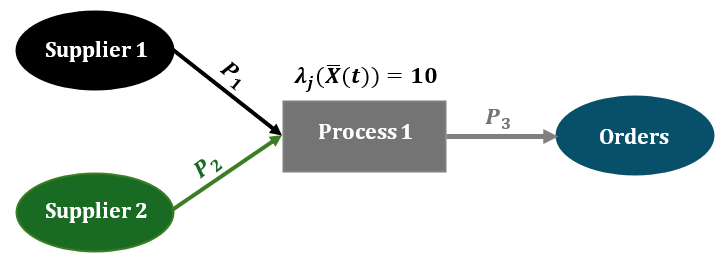
### $P_1 + P_2 \xrightarrow{\lambda_{1}} P_3$ 
### Inventory Management using Safety stock and safeguard constant Strategy for $\overline{X}_p(0) = 100$ for $p \in \{1,2\}$

In [56]:
# Problem setup
#=========================================================###=========================================================#
# Inputs
nd = 3                                      # total number of dimensions
J = 1                                       # total number of processes
N = 100                                     # number of Monte Carlo paths
T = 1000                                    # Total simulation time

inventories = np.array([100, 100, 0])

# safety stock
X_s = [30, 30]                     

# Safeguard
S_p = [30, 30]                     


#================================ Process time ranges t_min = pT[i,0], t_max = pT[i,1] ================================#
pT = np.array([[20, 20]])                    # shape (J,2)       with no delay start = end

#================================ Consumption vector ================================#
C_j_c = np.array([[-1],                   # consumes 1 unit of P1
                  [-1],                   # consumes 1 unit of P2
                  [0]])                   # P3 not consumed            # (3,1)

#================================ Production vector ================================#
C_j_p = np.array([[0],                     # P1 not produced
                  [0],                     # P2 not produced
                  [1]])                    # produces 1 unit of P3 # (3,1)

#================================ lambda_j values ================================#
lambda_j = np.array([5])
#=========================================================###=========================================================#

#======================= Plot colors =======================#
colors = ['Teal', 'Red', 'Blue']
labels = [r"$P_1$", r"$P_2$", r'$P_3$']

# Plot

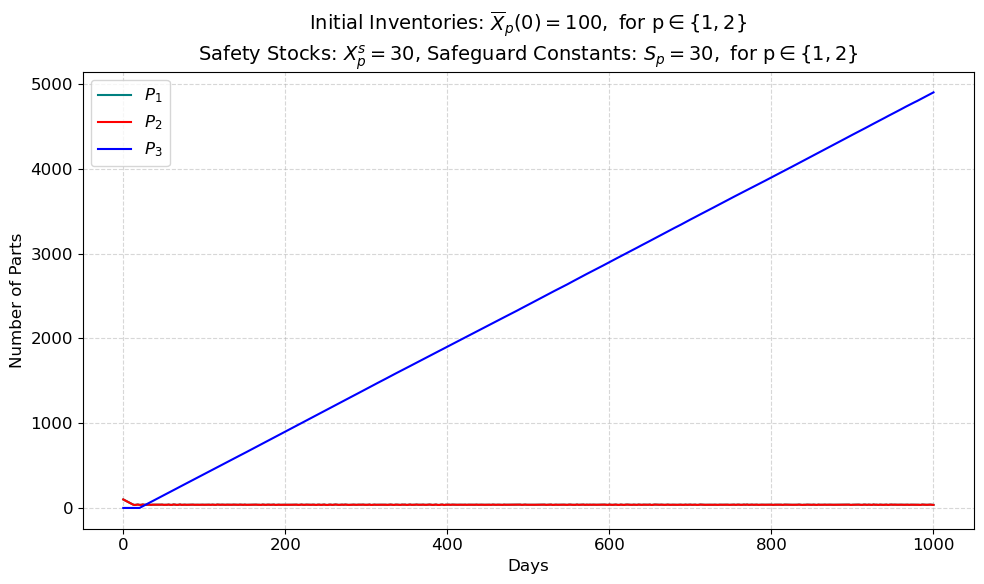

In [58]:
# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = 100,\ \rm{{for}}\ p \in \{{1,2\}}$' + '\n' + 
                                        fr'Safety Stocks: $X_p^s = {X_s[0]}$, Safeguard Constants: $S_p = {S_p[0]},\ \rm{{for}}\ p \in \{{1,2\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_3.png", format="png", bbox_inches="tight")
    plt.show()

# - Replenishment Order Strategy 2
### Supply Chain: 
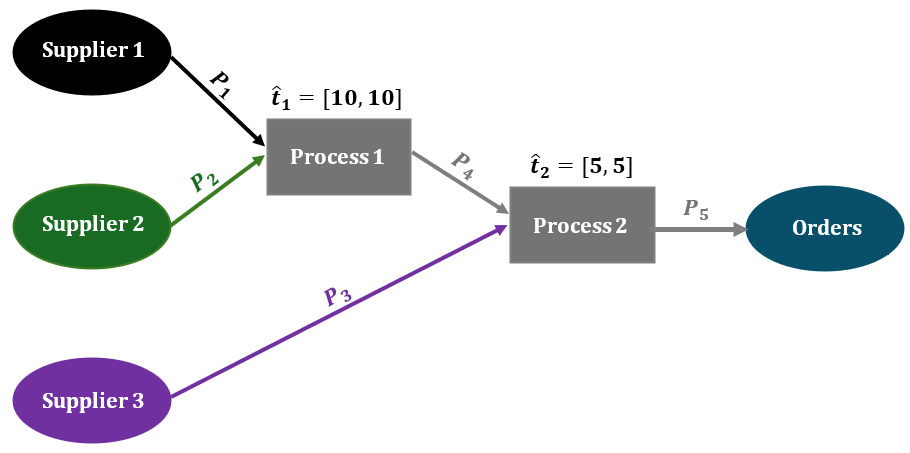
### $P_1 + P_2 \xrightarrow{\lambda_{1}(\overline{X}(t))} P_4$ and $P_3 + P_4 \xrightarrow{\lambda_{2}(\overline{X}(t))} P_5$  
### Inventory Management using Safety stock and safeguard constant Strategy for $\overline{X}_p(0) = 100$ for $p \in \{1,2,3\}$

In [63]:
# Problem setup
#=========================================================###=========================================================#
nd = 5                                        # total number of dimensions (number of parts)
J = 2                                         # total number of processes
N = 500                                     # number of Monte Carlo paths
T = 100                                    # Total simulation time
# T = 1000                                    # Total simulation time

inventories = np.array([10, 10, 10, 0, 0])                  

#================================ Process time ranges t_min = pT[i,0], t_max = pT[i,1] ================================#
pT = np.array([[0, 0], [0, 5]])                    # shape (J,2)       with no delay start = end


#================================ Consumption vector ================================#
C_j_c = np.array([[-1,  0],             # P1 consumed by process 1
                  [-1,  0],             # P2 consumed by process 1
                  [ 0, -1],             # P3 consumed by process 2
                  [ 0, -1],             # P4 consumed by process 2
                  [ 0,  0]])            # P5 not consumed  # shape (5, 2)


#================================ Production vector ================================#
C_j_p = np.array([[0, 0],                     # P1 not produced
                  [0, 0],                     # P2 not produced
                  [0, 0],                     # P3 not produced
                  [1, 0],                     # P4 produced by process 1
                  [0, 1]])                    # P5 produced by process 1    # shape (5,2)


#=========================================================###=========================================================#

#======================= Plot colors =======================#
colors = ['Orange', 'Purple', 'Cyan', 'Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$", r'$P_3$', r'$P_4$', r'$P_5$']

# Plot for $\lambda_1\left(\overline{X}(t)\right)=15 > \lambda_2\left(\overline{X}(t)\right)=10$

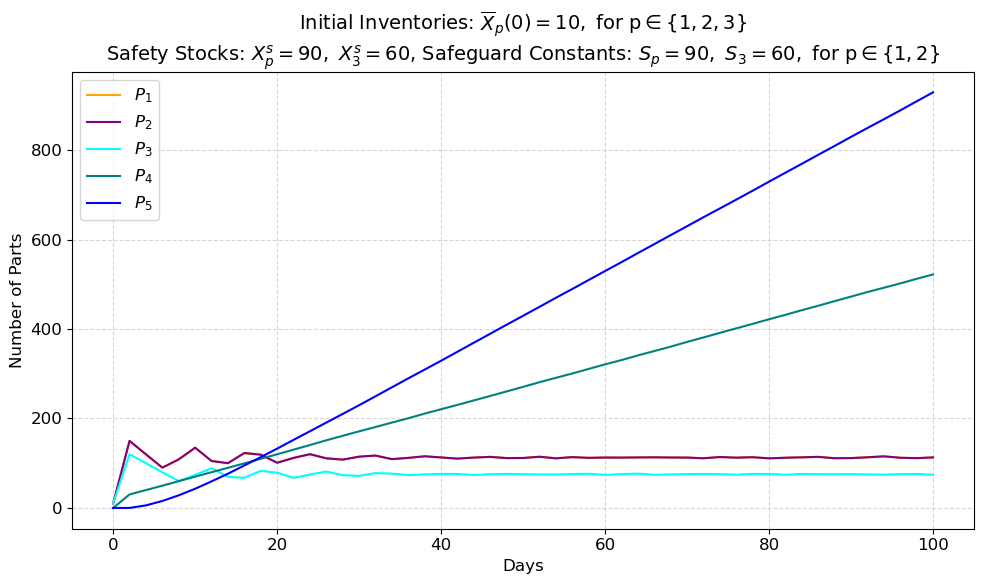

In [66]:
# safety stock
X_s = [90, 90, 60]              #(4/2 + 1)*(lambda_1(X(t)) = 15 * tau=2)  and (4/2 + 1)*(lambda_1(X(t)) = 10 * tau=2)                 

# Safeguard
S_p = [90, 90, 60]  

#================================ lambda_j values ================================#
lambda_j = np.array([15, 10])

# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])
    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {inventories[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$' + '\n' + 
    fr'Safety Stocks: $X_p^s = {X_s[0]},\ X_3^s = {X_s[2]}$, Safeguard Constants: $S_p = {S_p[0]},\ S_3 = {S_p[2]},\ \rm{{for}}\ p \in \{{1,2\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_4a.png", format="png", bbox_inches="tight")
    plt.show()

# Plot for $\lambda_1\left(\overline{X}(t)\right)=10 \leq \lambda_2\left(\overline{X}(t)\right)=10$

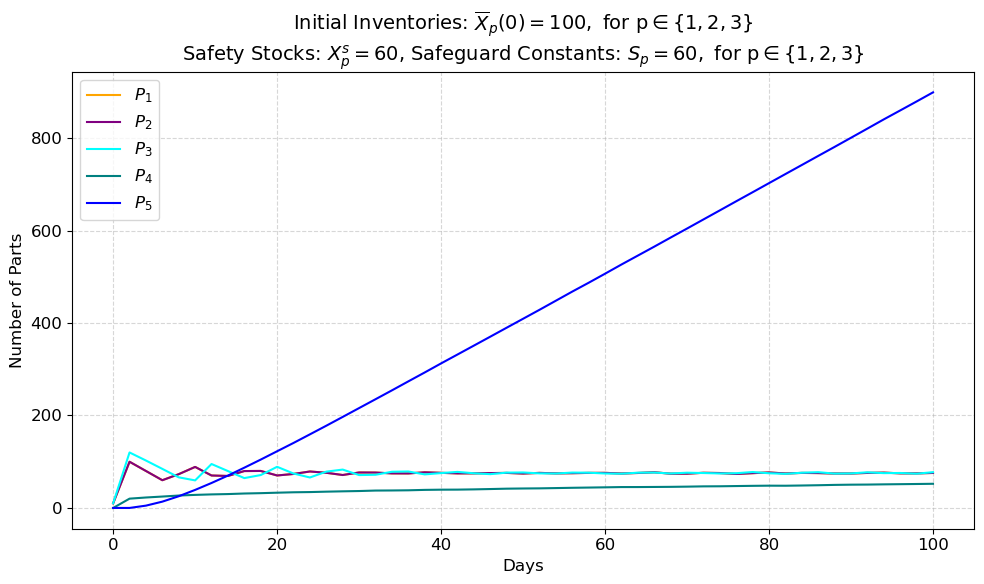

In [67]:
# safety stock
X_s = [60, 60, 60]              #(4/2 + 1)*(lambda_1(X(t)) = 10 * tau=2)                 

# Safeguard
S_p = [60, 60, 60]   

#================================ lambda_j values ================================#
lambda_j = np.array([10, 10])

# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = inventory_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories, X_s, S_p)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = 100,\ \rm{{for}}\ p \in \{{1,2,3\}}$' + '\n' + 
                                        fr'Safety Stocks: $X_p^s = {X_s[0]}$, Safeguard Constants: $S_p = {S_p[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_replenishment_4b.png", format="png", bbox_inches="tight")
    plt.show()

# - Birth Process Strategy for $X_1(0) = 100$
### Supply Chain:
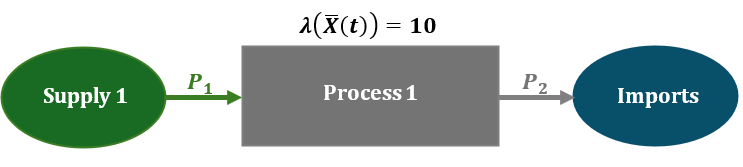
### $\emptyset \xrightarrow{\lambda_1(t,\overline{X}_1(t;\mu))=5} P_1$ and $P_1 \xrightarrow{\lambda_2(\overline{X}(t))=10} P_2$ 

In [14]:
#######################################################################################################################
# The stochastic push system function
# The starting point for the Stochastic Push System
def birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories):
    time = np.arange(0, T + tau, tau)
    num_steps = len(time)
    X_all = np.zeros((N, nd, num_steps))

    for r in range(N):
        X = np.zeros((nd, num_steps))
        count = 0
        X[:, count] = inventories
        queue_delay = []
        queue_count = 0
        t = 0

#######################################################################################################################
# Computing the Instantaneous consumption 
# Instantaneous consumption algorithm starts here
        
        while t < T:
            X[:, count + 1] = X[:, count]
            
            Delta_C_j = np.random.poisson(lambda_j * tau)

#============== Cap consumption based on available inventory ==================#
            for j in range(J):
                for i in range(nd):
                    if C_j_c[i, j] < 0:
                        max_possible = int(X[i, count + 1] / abs(C_j_c[i, j]))
                        Delta_C_j[j] = min(Delta_C_j[j], max_possible)

            X[:, count + 1] += C_j_c @ Delta_C_j

            for j in range(J):
                d_nq = j
                t_nq_s = t + pT[j, 0]
                Q_nq_d = Delta_C_j[j]
                t_span = tau + pT[j, 1] - pT[j, 0]
                queue_delay.append([d_nq, t_nq_s, Q_nq_d, t_span])
                queue_count += 1

# Instantaneous consumption algorithm ends here
#######################################################################################################################

#######################################################################################################################
# Compute the delayed production
# The delayed production algorithm Starts here

            if len(queue_delay) > 0:
                for d in range(len(queue_delay)):
                    d_nq, t_nq_s, Q_nq_d, t_span = queue_delay[d]
                    if t_span > 0 and (t_nq_s >= t and t_nq_s < t + tau):
                        prob = min(((t + tau - t_nq_s) / t_span), 1)
                        Delta_P_j = np.random.binomial(Q_nq_d, prob)
                        Q_nq_d -= Delta_P_j
                        t_nq_s = t + tau
                        t_span = max(0, t_span - (t + tau - t_nq_s))
                        queue_delay[d] = [d_nq, t_nq_s, Q_nq_d, t_span]

                        Delta_P_j_vec = np.zeros(J)
                        Delta_P_j_vec[d_nq] = Delta_P_j
                        X[:, count + 1] += C_j_p @ Delta_P_j_vec

            if (t + tau) >= T:
                tau = T - t
            t += tau
            count += 1
# The delayed production algorithm ends here
#######################################################################################################################

        X_all[r] = X

    # Average over all runs
    X_avg = np.mean(X_all, axis=0)                # axis = 0 helps to average the state vectors  down the columns (vertically)  
    return X_avg, time

#######################################################################################################################
#######################################################################################################################

In [15]:
# Simulation of result
# Inputs
nd = 2                                      # total number of dimensions
J = 2                                       # total number of processes
N = 500                                     # number of Monte Carlo paths
T = 100                                    # Total simulation time
# T = 1000                                    # Total simulation time
                                                 
inventories = np.array([10, 0])

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],                   # Process 1 empty --> P_1
               [5, 5]])                  # Process 2: P_1 --> P_2

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[0, -1],                # P1 not consumed
                  [0, 0]])                # P2 not consumed               # (2,2)

#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[1, 0],                # P1 is produced in Proc 1
                  [0, 1]])               # P2 is produced in proc 2

#======================= lambda_j values =======================#
lambda_j = np.array([5, 10])

#======================= Plot colors =======================#
colors = ['Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$"]

# Plot

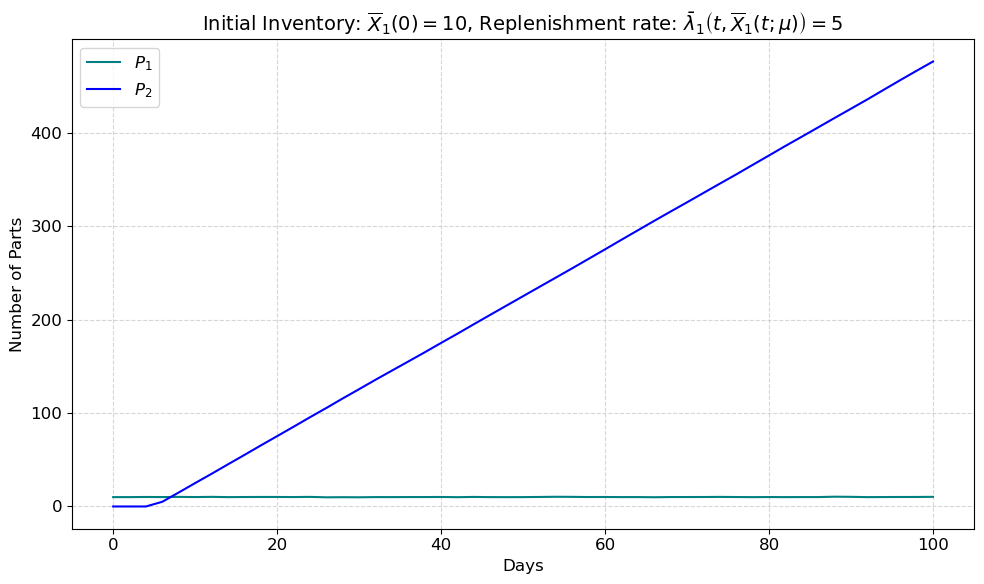

In [16]:
# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = {inventories[0]}$, Replenishment rate: $\bar{{\lambda}}_1\left(t,\overline{{X}}_1(t;\mu)\right)= {lambda_j[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_1.png", format="png", bbox_inches="tight")
    plt.show()

# Check what happens when $\lambda_1 (\rm{Replenishment ~rate}) > \lambda_2 (\rm{Consumption ~rate})$

In [20]:
# Simulation of result
# Inputs
nd = 2                                      # total number of dimensions
J = 2                                       # total number of processes
N = 100                                     # number of Monte Carlo paths
T = 100                                    # Total simulation time
                                                 
inventories = np.array([10, 0])

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],                   # Process 1 empty --> P_1
               [5, 5]])                 # Process 2: P_1 --> P_2

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[0, -1],                # P1 not consumed
                  [0, 0]])                # P2 not consumed               # (2,2)

#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[1, 0],                # P1 is produced in Proc 1
                  [0, 1]])               # P2 is produced in proc 2

#======================= lambda_j values =======================#
lambda_j = np.array([15, 10])

#======================= Plot colors =======================#
colors = ['Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$"]

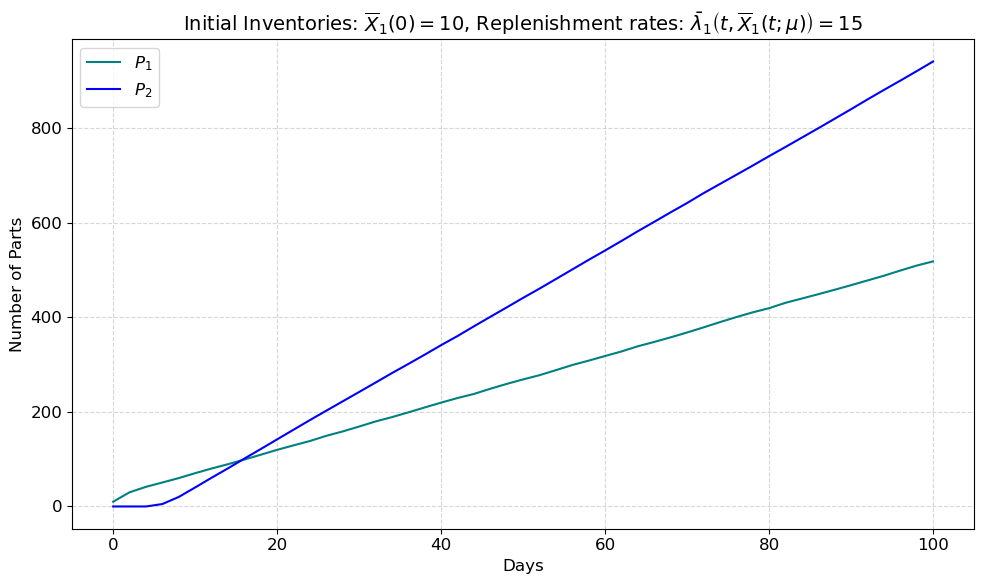

In [23]:
# Run for both taus and plot averages
taus = [2]  
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_1(0) = {inventories[0]}$, Replenishment rates: $\bar{{\lambda}}_1\left(t,\overline{{X}}_1(t;\mu)\right)= {lambda_j[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# - Birth Process Strategy for $X_1(0) = 100$
### Supply Chain:
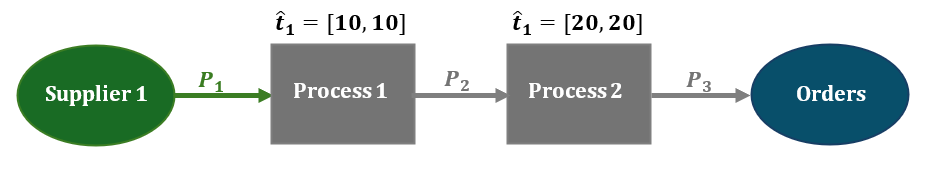
### $\emptyset \xrightarrow{\lambda_1(t,\overline{X}_1(t))=10} P_1$, $P_1 \xrightarrow{\lambda_2(\overline{X}(t))=10} P_2$ and $P_2 \xrightarrow{\lambda_3(\overline{X}(t))=5} P_3$ 

In [25]:
# Simulation of result
# Inputs
nd = 3                                     # total number of dimensions
J = 3                                      # total number of processes
N = 100                                    # number of Monte Carlo paths
T = 1000                                    # Total simulation time
                                                 
inventories = np.array([100, 0, 0])

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],                   # Process 1: empty --> P_1
               [10, 10],                   # Process 2: P_1 --> P_2
               [20, 20]])                 # Process 3: P_2 --> P_3

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[0, -1, 0],                # P1 consumed in proc 2
                  [0, 0, -1],                # P2 consumed in proc 3               # (3,3)
                  [0, 0, 0]])                # P3 not consumed

                  
#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[1, 0, 0],                # P1 is produced in Proc 1
                  [0, 1, 0],                # P2 is produced in proc 2
                  [0, 0, 1]])               # P3 is produced in proc 3

#======================= Plot colors =======================#
colors = ['Teal', 'Red', 'Blue']
labels = [r"$P_1$", r"$P_2$", r"$P_3$"]

# Plot for $\lambda_1\left(0,\overline{X}_1(0)\right)=10 > \lambda_3\left(\overline{X}(t)\right)=5$

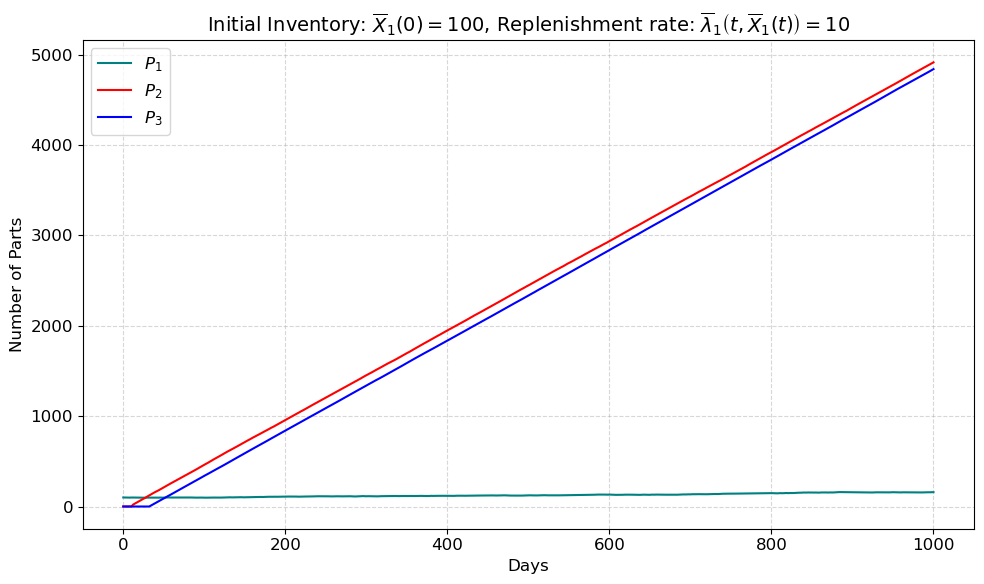

In [72]:
#======================= lambda_j values =======================#
lambda_j = np.array([10, 10, 5])


# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = 100$, Replenishment rate: $\overline{{\lambda}}_1\left(t,\overline{{X}}_1(t)\right)= {lambda_j[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_2a.png", format="png", bbox_inches="tight")
    plt.show()

# Plot for $\lambda_1\left(t,\overline{X}_1(t)\right)=5 \leq \lambda_3\left(\overline{X}(t)\right)=5$

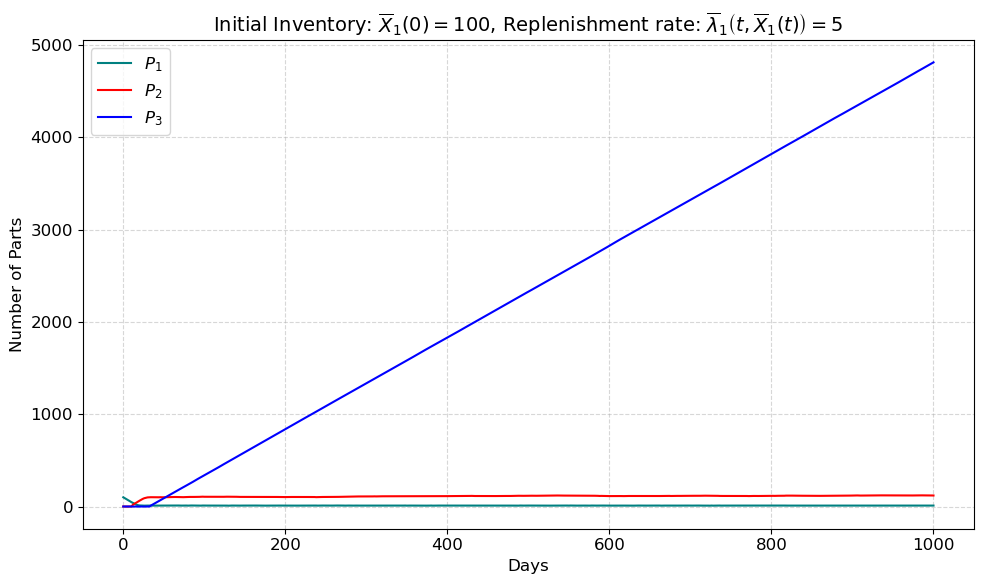

In [73]:
#======================= lambda_j values =======================#
lambda_j = np.array([5, 10, 5])

# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventory: $\overline{{X}}_1(0) = 100$, Replenishment rate: $\overline{{\lambda}}_1\left(t,\overline{{X}}_1(t)\right)= {lambda_j[0]}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_2b.png", format="png", bbox_inches="tight")
    plt.show()

# - Birth Process Strategy for $\overline{X}_p(0) = 100$ for $p \in \{1,2\}$
### Supply Chain: 
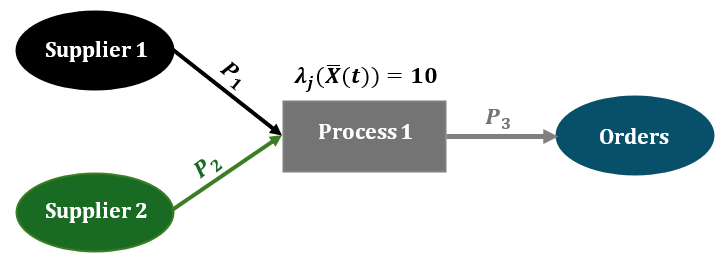
### $\emptyset \xrightarrow{\lambda_1(t,\overline{X}_1(t))=5} P_1,~~\emptyset \xrightarrow{\lambda_2(t,\overline{X}_2(t))=5} P_2~ \text{and}~ P_1 + P_2 \xrightarrow{\lambda_3(\overline{X}(t)) = 10} P_3$ 

In [74]:
# Simulation of result
# Inputs
nd = 3                                      # total number of dimensions
J = 3                                       # total number of processes
N = 100                                     # number of Monte Carlo paths
T = 1000                                    # Total simulation time
                                                 
inventories = np.array([100, 100, 0])

# Process time ranges t_min = pT[i,0], t_max = pT[i,1]
pT = np.array([[0, 0],                      # Process 1: empty --> P_1
               [0, 0],                      # Process 2: empty --> P_2
               [10, 10]])                   # Process 3: P_1 + P_2 --> P_3

#=================== Consumption vector (nd x J) =======================#
C_j_c = np.array([[0, 0, -1],                # P1 consumed in proc 3
                  [0, 0, -1],                # P2 consumed in proc 3               # (3,3)
                  [0, 0, 0]])                # P3 not consumed

                  
#=================== Production vector (nd x J) =======================#
C_j_p = np.array([[1, 0, 0],                # P1 is produced in Proc 1
                  [0, 1, 0],                # P2 is produced in proc 2
                  [0, 0, 1]])               # P3 is produced in proc 3

#======================= lambda_j values =======================#
lambda_j = np.array([5, 5, 10])

#======================= Plot colors =======================#
colors = ['Teal', 'red', 'Blue']
labels = [r"$P_1$", r"$P_2$", r"$P_3$"]

# Plot

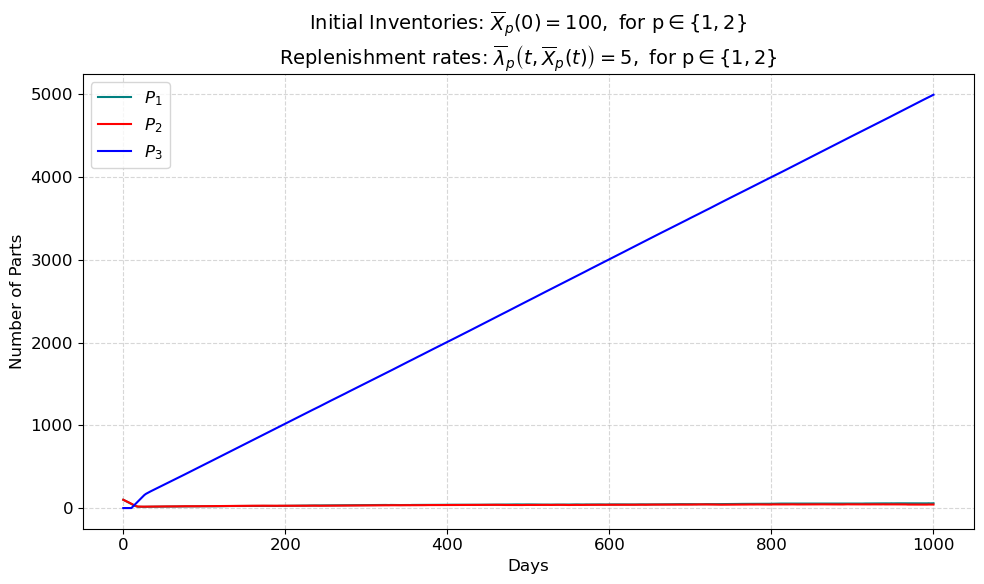

In [75]:
# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = 100,\ \rm{{for}}\ p \in \{{1,2\}}$' +'\n'+ 
              fr'Replenishment rates: $\overline{{\lambda}}_p\left(t,\overline{{X}}_p(t)\right)= {lambda_j[0]},\ \rm{{for}}\ p \in \{{1,2\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_3.png", format="png", bbox_inches="tight")
    plt.show()

# - Birth Process Strategy for $\overline{X}_p(0) = 100$ for $p \in \{1,2,3\}$
### Supply Chain: 
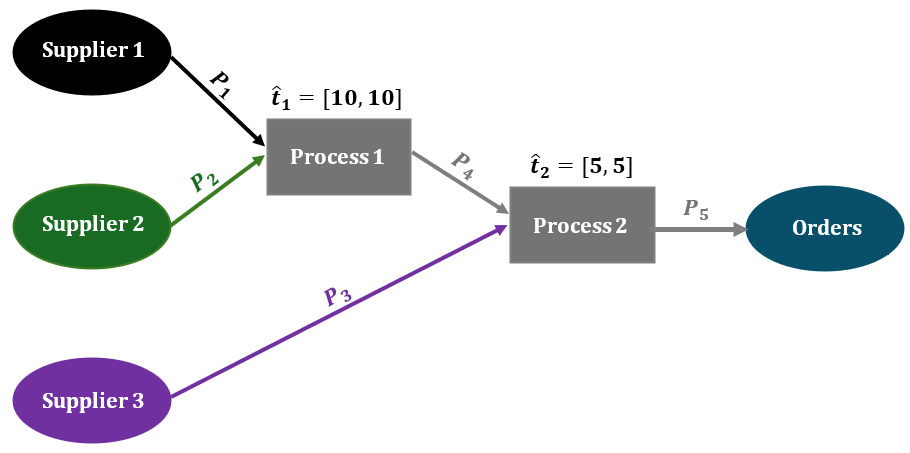
### $\emptyset \xrightarrow{\lambda_1(t,\overline{X}_1(t))=15} P_1,~~\emptyset \xrightarrow{\lambda_2(t,\overline{X}_2(t))=15} P_2,~~~\emptyset \xrightarrow{\lambda_2(t,\overline{X}_2(t))=15} P_3,~~~P_1 +P_2 \xrightarrow{\lambda_3(\overline{X}(t)) = 10} P_4~~ \text{and}~~  P_3 +P_4 \xrightarrow{\lambda_3(\overline{X}(t)) = 10} P_5$ 

In [26]:
# Problem setup
#=========================================================###=========================================================#
nd = 5                                        # total number of dimensions (number of parts)
J = 5                                         # total number of processes
N = 500                                       # number of Monte Carlo paths
T = 100                                      # Total simulation time

inventories = np.array([10, 10, 10, 0, 0])
                   

#================================ Process time ranges t_min = pT[i,0], t_max = pT[i,1] ================================#
pT = np.array([[0, 0], [0, 0], [0, 0], [0, 0], [0, 5]])                    # shape (J,2)       with no delay start = end


#================================ Consumption vector ================================#
C_j_c = np.array([[0, 0, 0, -1, 0],             # P1 consumed by process 4
                  [0, 0, 0, -1, 0],             # P2 consumed by process 4
                  [0, 0, 0, 0, -1],             # P3 consumed by process 5
                  [0, 0, 0, 0, -1],             # P4 consumed by process 5
                  [0, 0, 0, 0,  0]])            # P5 not consumed  # shape (5, 5)


#================================ Production vector ================================#
C_j_p = np.array([[1, 0, 0, 0, 0],                     # P1 is produced in proc 1
                  [0, 1, 0, 0, 0],                     # P2 is produced in proc 2
                  [0, 0, 1, 0, 0],                     # P3 is produced in proc 3
                  [0, 0, 0, 1, 0],                     # P4 produced by process 4
                  [0, 0, 0, 0, 1]])                    # P5 produced by process 5    # shape (5,2)

#======================= Plot colors =======================#
colors = ['Orange', 'Purple', 'Cyan', 'Teal', 'Blue']
labels = [r"$P_1$", r"$P_2$", r'$P_3$', r'$P_4$', r'$P_5$']

# Plot for $\lambda_p\left(t,\overline{X}_p(t)\right)=15~\rm{for}~p \in \{{1,2,3\}} > \lambda_5\left(\overline{X}(t)\right)=10$

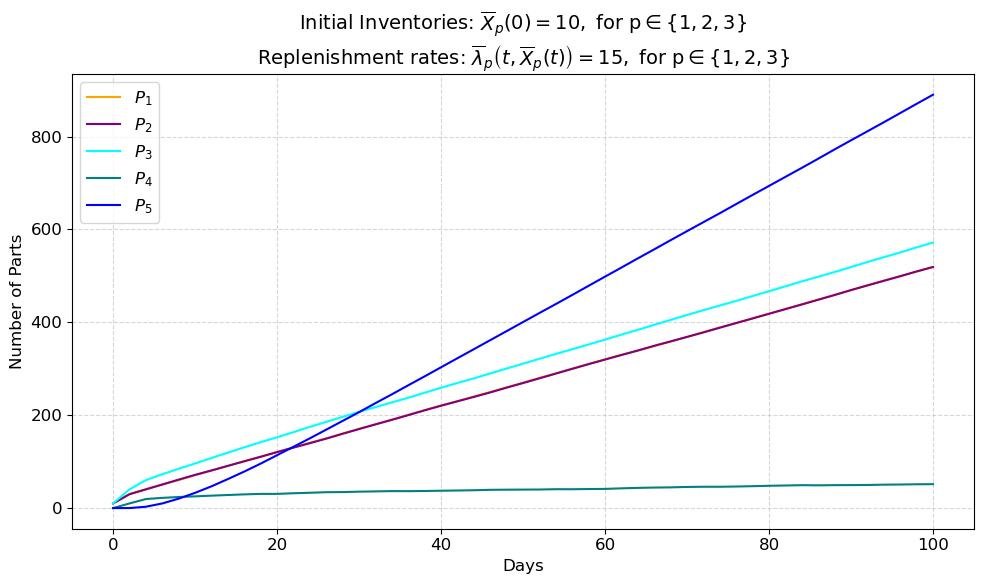

In [82]:
#================================ lambda_j values ================================#
lambda_j = np.array([15, 15, 15, 10, 10])

# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {inventories[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$' +'\n'+ 
              fr'Replenishment rates: $\overline{{\lambda}}_p\left(t,\overline{{X}}_p(t)\right)= {lambda_j[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_4a.png", format="png", bbox_inches="tight")
    plt.show()

# Plot for $\lambda_p\left(t,\overline{X}_p(t;\mu)\right)=10~\rm{for}~p \in \{{1,2,3\}} \leq \lambda_5\left(\overline{X}(t)\right)=10$

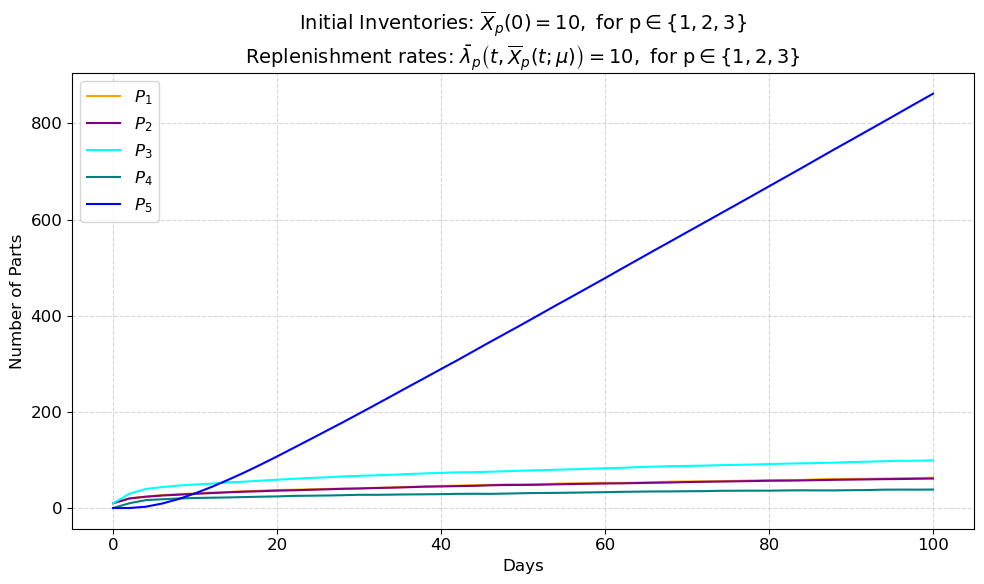

In [28]:
#================================ lambda_j values ================================#
lambda_j = np.array([10, 10, 10, 10, 10])

# Run for both taus and plot averages
taus = [2] 
for tau in taus:
    X_avg, time = birth_process_basic_sc(nd, J, N, T, tau, pT, C_j_c, C_j_p, lambda_j, inventories)

    plt.figure(figsize=(10, 6))
    for i in range(nd):
        plt.plot(time, X_avg[i], color=colors[i], label = labels[i])

    plt.title(fr'Initial Inventories: $\overline{{X}}_p(0) = {inventories[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$' +'\n'+ 
              fr'Replenishment rates: $\bar{{\lambda}}_p\left(t,\overline{{X}}_p(t;\mu)\right)= {lambda_j[0]},\ \rm{{for}}\ p \in \{{1,2,3\}}$')
    plt.ylabel('Number of Parts')
    plt.xlabel('Days')
    plt.legend()

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("basic_sc_birth_process_4b.png", format="png", bbox_inches="tight")
    plt.show()